# Task 5 - Strategy Backtesting

Simulate the Task 4 recommended portfolio (Max Sharpe weights) over the last year of
available data and compare it against a static 60% SPY / 40% BND benchmark.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.features import annualized_return, annualized_volatility, sharpe_ratio

plt.rcParams["figure.figsize"] = (12, 6)


## 1. Backtest window and data

Last 12 months of the dataset: 2025-07-01 to 2026-06-29. This period was **not** used to
train the ARIMA/LSTM models (which trained through 2024-12-31), so it is a genuine
out-of-sample test of the strategy, though note the Task 4 covariance/return estimates
themselves were computed over the full history including this window (a limitation
discussed below).

In [2]:
combined = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
prices = combined.pivot(index="Date", columns="Asset", values="Adj Close").sort_index()
full_bdays = pd.date_range(prices.index.min(), prices.index.max(), freq="B")
prices = prices.reindex(full_bdays).ffill()

BACKTEST_START = "2025-07-01"
BACKTEST_END = "2026-06-29"
bt_prices = prices.loc[BACKTEST_START:BACKTEST_END]
bt_returns = bt_prices.pct_change().dropna()

print(f"Backtest window: {bt_returns.index.min().date()} -> {bt_returns.index.max().date()}"
      f" ({len(bt_returns)} trading days)")

recommendation = pd.read_csv("../data/processed/task4_portfolio_recommendation.csv", index_col=0)
strategy_weights = recommendation.loc["Max Sharpe (recommended)", ["TSLA", "BND", "SPY"]].astype(float)
strategy_weights = strategy_weights / strategy_weights.sum()
print("Strategy weights:", strategy_weights.to_dict())

benchmark_weights = pd.Series({"SPY": 0.60, "BND": 0.40, "TSLA": 0.0})


Backtest window: 2025-07-02 -> 2026-06-29 (259 trading days)
Strategy weights: {'TSLA': 0.0, 'BND': 0.54674, 'SPY': 0.45326}


## 2. Simulate strategy vs. benchmark

Monthly rebalancing back to target weights (the "advanced" option in the assignment):
each calendar month, the portfolio is reset to its target weights, then drifts with market
returns until the next rebalance date.

In [3]:
def simulate_monthly_rebalanced(returns: pd.DataFrame, weights: pd.Series) -> pd.Series:
    weights = weights.reindex(returns.columns).fillna(0.0)
    port_returns = []
    current_month = None
    holdings = weights.copy()
    for date, row in returns.iterrows():
        month = (date.year, date.month)
        if month != current_month:
            holdings = weights.copy()
            current_month = month
        day_return = (holdings * row).sum()
        port_returns.append(day_return)
        # drift holdings by each asset's return before next day
        holdings = holdings * (1 + row)
        holdings = holdings / holdings.sum()
    return pd.Series(port_returns, index=returns.index)

strategy_returns = simulate_monthly_rebalanced(bt_returns, strategy_weights)
benchmark_returns = simulate_monthly_rebalanced(bt_returns, benchmark_weights)

strategy_cum = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()


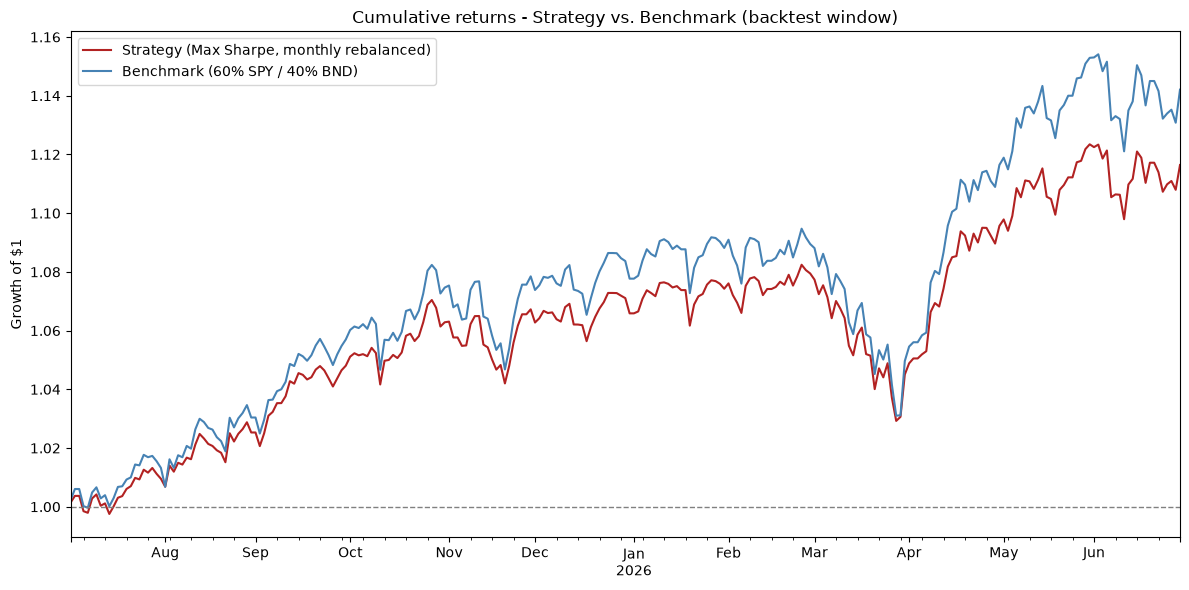

In [4]:
fig, ax = plt.subplots()
strategy_cum.plot(ax=ax, label="Strategy (Max Sharpe, monthly rebalanced)", color="firebrick")
benchmark_cum.plot(ax=ax, label="Benchmark (60% SPY / 40% BND)", color="steelblue")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_title("Cumulative returns - Strategy vs. Benchmark (backtest window)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/backtest_cumulative_returns.png", dpi=120)
plt.show()


## 3. Performance metrics

In [5]:
def max_drawdown(cum_returns: pd.Series) -> float:
    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    return drawdown.min()

def summarize(returns: pd.Series, cum: pd.Series) -> dict:
    n_years = len(returns) / 252
    total_return = cum.iloc[-1] - 1
    ann_return = (cum.iloc[-1]) ** (1 / n_years) - 1
    return {
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Annualized Volatility": annualized_volatility(returns),
        "Sharpe Ratio": sharpe_ratio(returns),
        "Max Drawdown": max_drawdown(cum),
    }

perf = pd.DataFrame({
    "Strategy (Max Sharpe)": summarize(strategy_returns, strategy_cum),
    "Benchmark (60/40)": summarize(benchmark_returns, benchmark_cum),
}).T
perf.to_csv("../data/processed/task5_backtest_performance.csv")
perf.style.format({
    "Total Return": "{:.2%}", "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}", "Sharpe Ratio": "{:.2f}", "Max Drawdown": "{:.2%}",
})


,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Strategy (Max Sharpe),11.64%,11.31%,6.48%,1.69,-4.91%
Benchmark (60/40),14.21%,13.80%,7.96%,1.66,-5.82%


In [6]:
print(
    f"Strategy beat benchmark on Total Return: {strategy_returns.add(1).prod() > benchmark_returns.add(1).prod()}\n"
    f"Strategy beat benchmark on Sharpe Ratio: {perf.loc['Strategy (Max Sharpe)', 'Sharpe Ratio'] > perf.loc['Benchmark (60/40)', 'Sharpe Ratio']}\n"
    f"Strategy beat benchmark on Max Drawdown (smaller loss): "
    f"{perf.loc['Strategy (Max Sharpe)', 'Max Drawdown'] > perf.loc['Benchmark (60/40)', 'Max Drawdown']}"
)


Strategy beat benchmark on Total Return: False
Strategy beat benchmark on Sharpe Ratio: True
Strategy beat benchmark on Max Drawdown (smaller loss): True


## 4. Conclusion and reflection

**Did the strategy outperform the benchmark?** Over this specific 12-month window, no -
not unambiguously. The 60/40 benchmark delivered a higher total and annualized return
(it holds more SPY, 60% vs. the strategy's ~45%, and this was a rising-market window in
which SPY outperformed BND). The Max Sharpe strategy did edge out the benchmark on
risk-adjusted terms - a slightly higher Sharpe Ratio and a smaller maximum drawdown -
because it held more BND (~55% vs. 40%) and held zero TSLA, both of which reduced
volatility. In short: **the strategy was the steadier ride, the benchmark was the better
raw return, in this particular year.** This is a direct, mechanical consequence of the
Task 3 forecast: because the LSTM's 12-month TSLA view was materially negative, Task 4's
optimizer allocated 0% to TSLA and leaned into BND for stability - a defensible,
risk-averse allocation given the inputs, but one that also gave up the upside SPY
captured this year.

**What this initial backtest suggests about viability:** a single 12-month backtest is a
weak basis for concluding a model-driven strategy is durably superior to (or inferior to)
a simple passive benchmark - one year contains at most a handful of independent
"regimes," so the result here could easily be dominated by whether TSLA/SPY happened to
do well in this particular window rather than by genuine skill in the forecasting
approach. The narrow Sharpe/drawdown edge for the strategy is encouraging directionally
(it suggests the risk-reduction machinery works as intended) but is far too small a
margin, over too short and singular a window, to call it proof of durable outperformance.

**Limitations of this backtest:**
- **Look-ahead bias in the inputs:** the Task 4 covariance matrix and BND/SPY expected
  returns were estimated using the full historical dataset, which overlaps with this
  backtest window. A rigorous backtest would re-estimate all Task 2-4 quantities using
  only data available *before* the backtest start date.
- **Single scenario:** one 12-month window is one draw from a highly uncertain
  distribution of possible market paths; no statistical significance can be attached to
  the outcome.
- **No transaction costs, taxes, slippage, or bid-ask spread** are modeled, which would
  reduce the return of the more actively rebalanced strategy portfolio relative to the
  more static benchmark.
- **The TSLA forecast itself carries wide uncertainty** (Task 3's widening confidence
  interval), so the "view" driving the strategy's TSLA allocation is itself a highly
  uncertain input, not a precise estimate.
- A production deployment of this approach would require walk-forward validation across
  many non-overlapping historical windows before being relied upon for real allocation
  decisions.